In [1]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 15.3 MB/s eta 0:00:00a 0:00:01


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, f1_score
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

import skfuzzy as fuzz
from tensorflow.keras import layers, models

2026-03-12 04:36:39.847643: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773290200.060006      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773290200.120990      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773290200.639303      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773290200.639345      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773290200.639348      55 computation_placer.cc:177] computation placer alr

In [3]:
df = pd.read_csv('/kaggle/input/lowdr7lamost.csv', sep='|', engine='python')

In [4]:
df.describe()

,combined_obsid,combined_lmjd,combined_mjd,combined_spid,combined_fiberid,combined_z,combined_ra,combined_dec,combined_logg,combined_feh,combined_teff,combined_rv,combined_m_h
count,6.759593e+06,6.759593e+06,6.759593e+06,6.759593e+06,6.759593e+06,6.759593e+06,6.759593e+06,6.759593e+06,5.919883e+06,5.743502e+06,5.919883e+06,5.743502e+06,170634.000000
mean,3.342138e+08,5.712801e+04,5.712701e+04,8.433005e+00,1.260223e+02,-1.495528e+00,1.436772e+02,2.666133e+01,-9.681815e+00,-2.352946e-01,5.528113e+03,-8.612024e+00,-360.830770
std,1.954245e+08,6.947059e+02,6.947059e+02,4.568767e+00,7.097084e+01,1.222755e+02,9.130852e+01,1.677645e+01,3.700114e+02,3.424437e-01,1.176904e+03,4.636232e+01,1863.838084
min,1.010010e+05,5.585900e+04,5.585800e+04,1.000000e+00,1.000000e+00,-9.999000e+03,1.100000e-04,-9.906984e+00,-9.999000e+03,-2.500000e+00,-9.999000e+03,-4.993100e+02,-9999.000000
25%,1.745160e+08,5.660300e+04,5.660200e+04,4.000000e+00,6.500000e+01,-1.083416e-04,7.829078e+01,1.381991e+01,3.937000e+00,-4.130000e-01,4.957875e+03,-3.278000e+01,-0.681000
50%,3.081111e+08,5.705300e+04,5.705200e+04,8.000000e+00,1.260000e+02,-2.461700e-05,1.207342e+02,2.681180e+01,4.197000e+00,-1.960000e-01,5.596000e+03,-8.100000e+00,-0.400000
75%,4.806110e+08,5.769700e+04,5.769600e+04,1.200000e+01,1.870000e+02,6.107560e-05,2.049242e+02,4.005842e+01,4.457000e+00,-8.000000e-03,6.037510e+03,1.721000e+01,-0.033000
max,7.469152e+08,5.864300e+04,5.864200e+04,1.600000e+01,2.500000e+02,1.995510e+00,3.599999e+02,8.311561e+01,9.748000e+00,1.000000e+00,7.569935e+04,4.981000e+02,0.500000


In [5]:
df.shape

(6759593, 17)

In [6]:
df.isna().sum()

combined_obsid             0
combined_obsdate           0
combined_lmjd              0
combined_mjd               0
combined_planid            0
combined_spid              0
combined_fiberid           0
combined_class             0
combined_subclass          0
combined_z                 0
combined_ra                0
combined_dec               0
combined_logg         839710
combined_feh         1016091
combined_teff         839710
combined_rv          1016091
combined_m_h         6588959
dtype: int64

### cleaning

In [7]:
df = df.drop_duplicates()

In [8]:
df.shape

(6759593, 17)

In [9]:
df = df.dropna(subset=['combined_teff', 'combined_logg', 'combined_feh', 'combined_z'])

In [10]:
df.shape

(5743502, 17)

In [11]:
df.isna().sum()

combined_obsid             0
combined_obsdate           0
combined_lmjd              0
combined_mjd               0
combined_planid            0
combined_spid              0
combined_fiberid           0
combined_class             0
combined_subclass          0
combined_z                 0
combined_ra                0
combined_dec               0
combined_logg              0
combined_feh               0
combined_teff              0
combined_rv                0
combined_m_h         5743502
dtype: int64

In [12]:
df['combined_spectral_class'] = df['combined_subclass'].str[0]

In [13]:
df['combined_spectral_class'].unique()

array(['G', 'F', 'K', 'A'], dtype=object)

In [14]:
for i in df['combined_spectral_class'].unique():
    print(f'{i}:', sum((df['combined_spectral_class'] == i) == True)/df.shape[0]*100, '%')

G: 50.8944020564457 %
F: 31.475604953214955 %
K: 15.66121157440182 %
A: 1.9687814159375236 %


#### Unavailability of Class O, A, M is a DR7 limitation or survey limitation

In [15]:
spectral_order = {
    'A': 0,
    'F': 1,
    'G': 2,
    'K': 3
}

df['combined_spectral_label'] = df['combined_spectral_class'].map(spectral_order)

## Intent: I want a fair classifier for all present classes (A, F, G, K)

# Data Visualization

/tmp/ipykernel_55/511643903.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='combined_spectral_class', palette='viridis', order=df['combined_spectral_class'].value_counts().index)


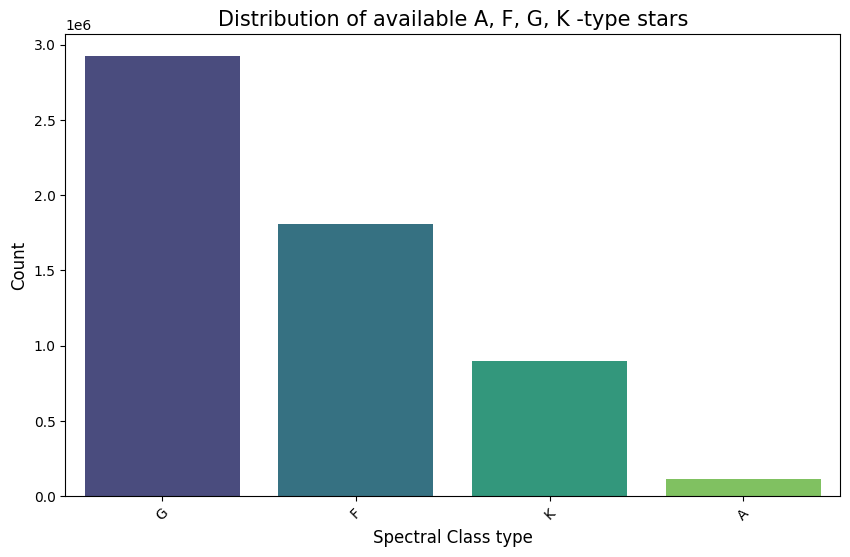

In [16]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='combined_spectral_class', palette='viridis', order=df['combined_spectral_class'].value_counts().index)

plt.title('Distribution of available A, F, G, K -type stars', fontsize=15)
plt.xlabel('Spectral Class type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.show()

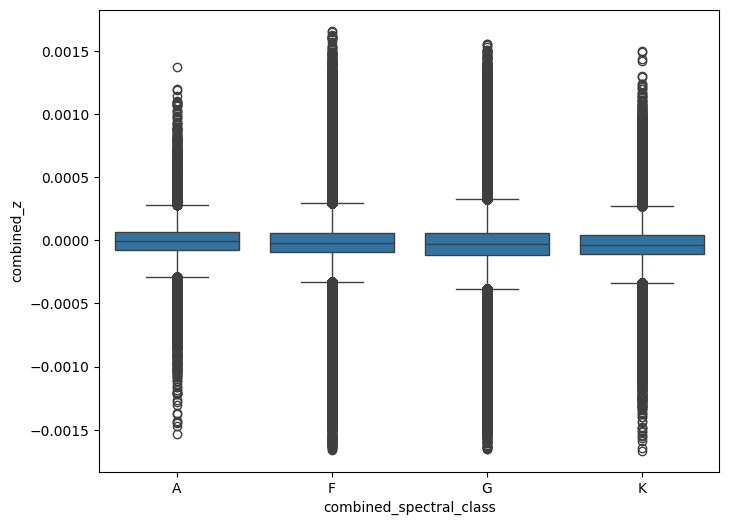

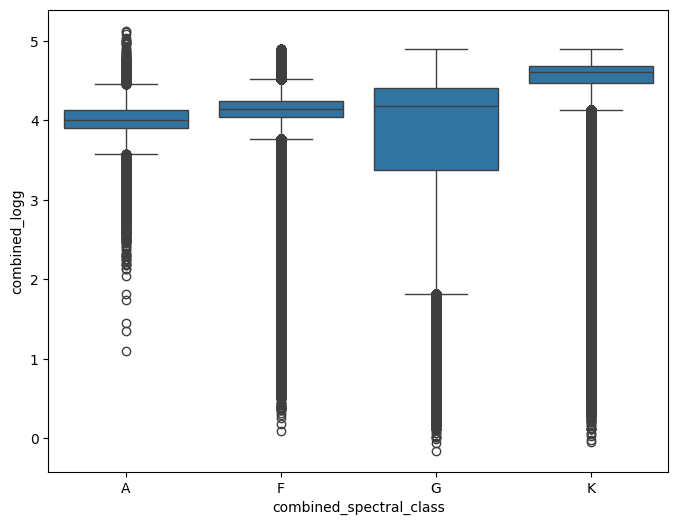

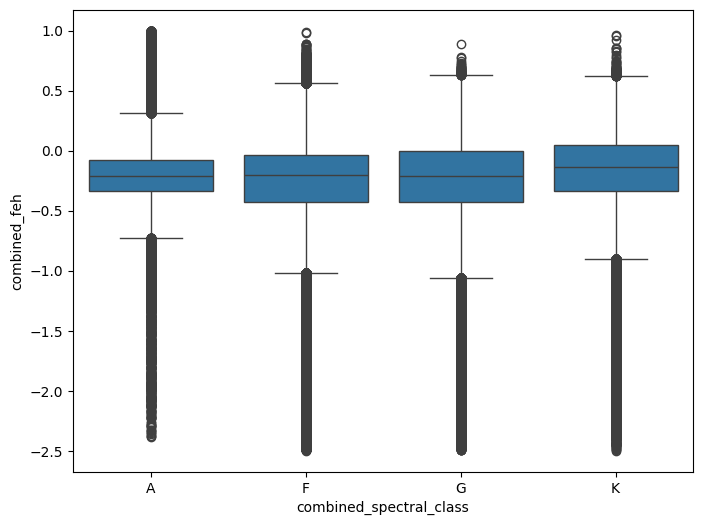

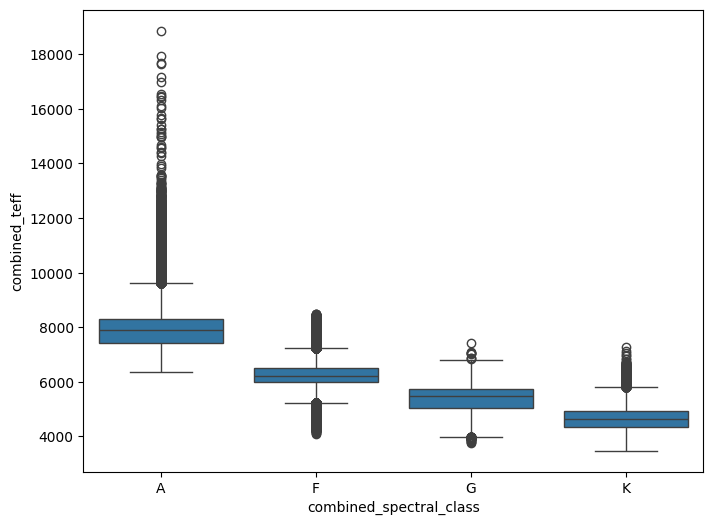

In [17]:
effective_features = ['combined_z', 'combined_logg', 'combined_feh', 'combined_teff',]

for i in effective_features:
    plt.figure(figsize=(8,6))
    sns.boxplot(
        x='combined_spectral_class',
        y=i,
        data=df,
        order=['A','F','G','K']
    )
    plt.show()

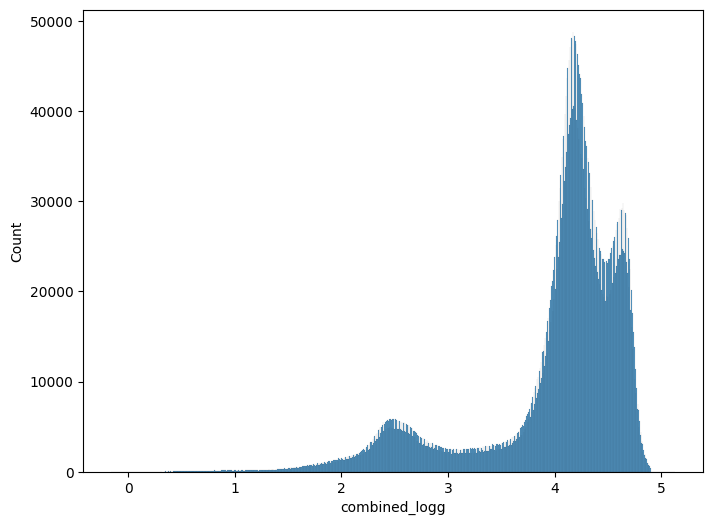

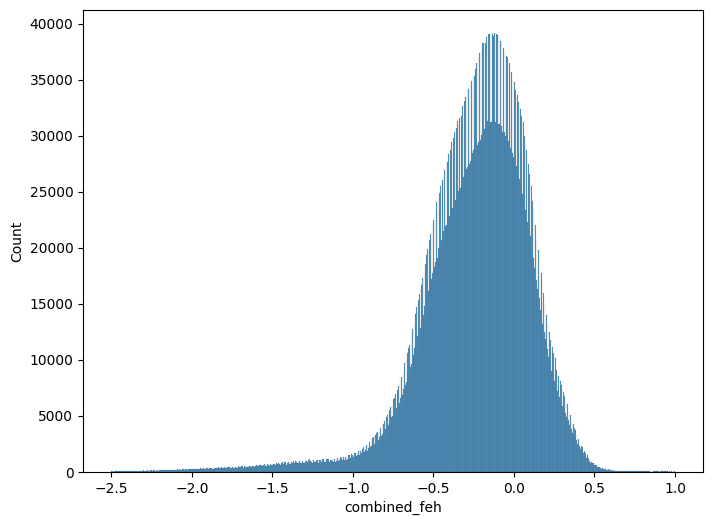

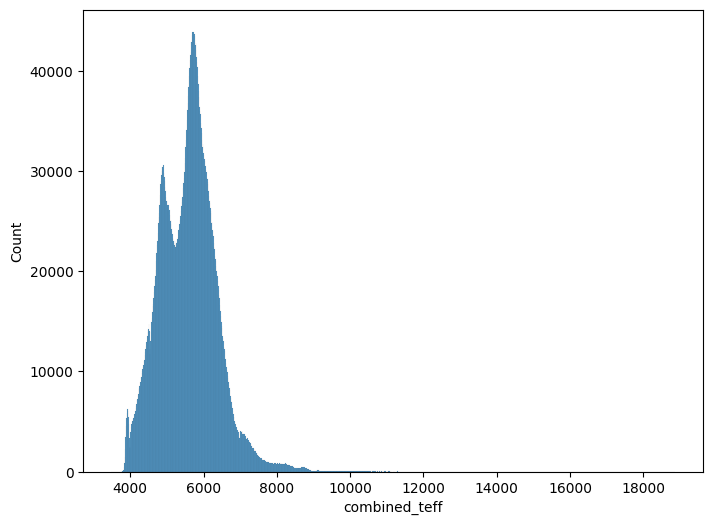

In [18]:
effective_features = [ 'combined_logg', 'combined_feh', 'combined_teff']
for col in effective_features:
    figure = plt.figure(figsize=(8,6))
    sns.histplot(df[col])
plt.show()

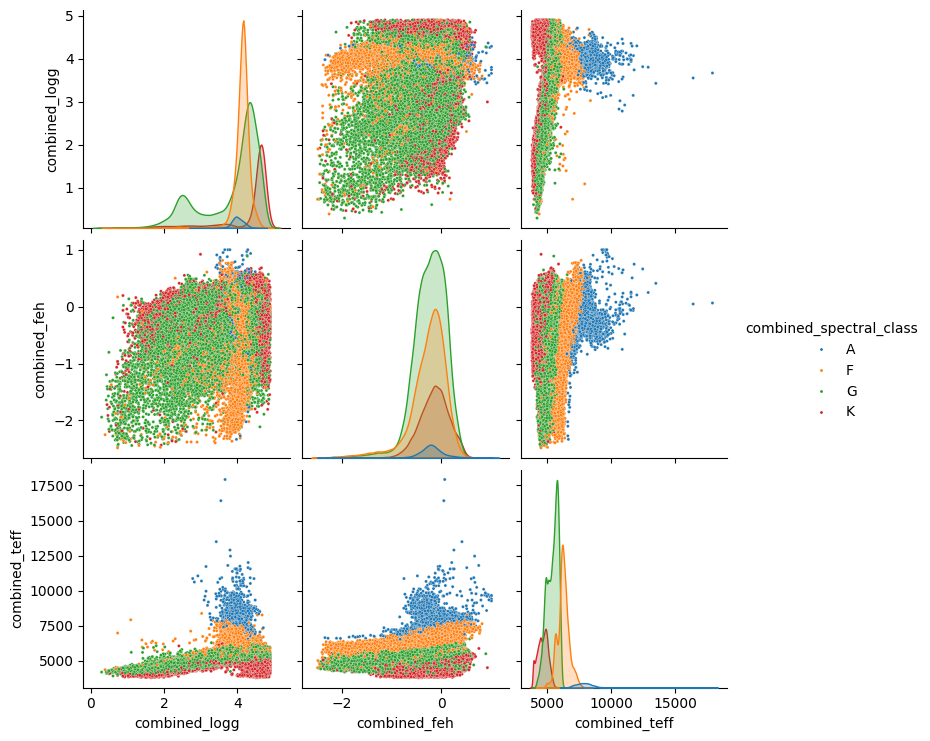

In [19]:
effective_features = ['combined_logg', 'combined_feh', 'combined_teff']
sns.pairplot(
    df.sample(200000),
    vars=effective_features,
    hue='combined_spectral_class',
    hue_order=['A','F','G','K'],
    plot_kws={'s':5}
)
plt.show()

In [20]:
df

,combined_obsid,combined_obsdate,combined_lmjd,combined_mjd,combined_planid,combined_spid,combined_fiberid,combined_class,combined_subclass,combined_z,combined_ra,combined_dec,combined_logg,combined_feh,combined_teff,combined_rv,combined_m_h,combined_spectral_class,combined_spectral_label
0,164907060,2013-10-15,56581,56580,VB013N21V2,7,60,STAR,G3,0.000111,14.375441,19.921242,4.312,-0.141,5810.55,33.17,NaN,G,2
1,164907066,2013-10-15,56581,56580,VB013N21V2,7,66,STAR,F2,-0.000073,14.529226,19.623526,4.220,-0.413,5990.69,-21.89,NaN,F,1
2,164907069,2013-10-15,56581,56580,VB013N21V2,7,69,STAR,K1,-0.000012,14.446834,19.939219,4.478,0.363,5400.07,-3.51,NaN,K,3
3,164907070,2013-10-15,56581,56580,VB013N21V2,7,70,STAR,G4,-0.000102,14.621107,19.635723,4.288,0.120,5637.44,-30.49,NaN,G,2
4,164907071,2013-10-15,56581,56580,VB013N21V2,7,71,STAR,G9,-0.000202,14.449030,19.726528,3.548,-0.399,5040.92,-60.45,NaN,G,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6759588,164907045,2013-10-15,56581,56580,VB013N21V2,7,45,STAR,G5,0.000077,13.711688,19.509445,2.766,-0.122,5085.20,23.22,NaN,G,2
6759589,164907049,2013-10-15,56581,56580,VB013N21V2,7,49,STAR,G7,-0.000054,13.627372,19.564133,2.373,-0.488,4901.15,-16.08,NaN,G,2
6759590,164907052,2013-10-15,56581,56580,VB013N21V2,7,52,STAR,G9,0.000116,14.522174,19.957779,4.597,-0.595,4928.62,34.81,NaN,G,2
6759591,164907055,2013-10-15,56581,56580,VB013N21V2,7,55,STAR,G2,0.000118,14.470172,19.743355,4.397,-0.054,5924.03,35.26,NaN,G,2


In [21]:
effective_features = ['combined_logg', 'combined_feh', 'combined_teff']
X = df[effective_features].values
y = df['combined_spectral_label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### Fuzzy CMeans Clustering (C=4)

In [22]:
X_fcm = X_scaled.T

cntr, u, _, _, _, _, fpc = fuzz.cluster.cmeans(
    data=X_fcm,
    c=4,
    m=2.0,
    error=1e-5,
    maxiter=1000,
    seed=42
)

X_fuzzy = u.T   # (N, 4)


In [23]:
X_final = np.hstack([X_scaled, X_fuzzy])
print("Final feature shape:", X_final.shape)


Final feature shape: (5743502, 7)


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)


### FFNN for fuzzy inputs

In [25]:
model = models.Sequential([
    layers.Input(shape=(X_final.shape[1],)),

    layers.Dense(64),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),

    layers.Dense(32),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),

    layers.Dense(4, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


I0000 00:00:1773290906.742670      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773290906.748633      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [26]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

## Train

In [27]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50


I0000 00:00:1773290910.302969     133 service.cc:152] XLA service 0x7f5348006980 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773290910.303005     133 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773290910.303009     133 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773290910.682557     133 cuda_dnn.cc:529] Loaded cuDNN version 91002


   71/14359 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step - accuracy: 0.4497 - loss: 1.3611  

I0000 00:00:1773290912.780267     133 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


14359/14359 ━━━━━━━━━━━━━━━━━━━━ 44s 3ms/step - accuracy: 0.8480 - loss: 0.3887 - val_accuracy: 0.8854 - val_loss: 0.2800
Epoch 2/50
14359/14359 ━━━━━━━━━━━━━━━━━━━━ 37s 3ms/step - accuracy: 0.8719 - loss: 0.3170 - val_accuracy: 0.8855 - val_loss: 0.2759
Epoch 3/50
14359/14359 ━━━━━━━━━━━━━━━━━━━━ 37s 3ms/step - accuracy: 0.8731 - loss: 0.3146 - val_accuracy: 0.8857 - val_loss: 0.2761
Epoch 4/50
14359/14359 ━━━━━━━━━━━━━━━━━━━━ 37s 3ms/step - accuracy: 0.8739 - loss: 0.3117 - val_accuracy: 0.8863 - val_loss: 0.2754
Epoch 5/50
14359/14359 ━━━━━━━━━━━━━━━━━━━━ 37s 3ms/step - accuracy: 0.8745 - loss: 0.3113 - val_accuracy: 0.8867 - val_loss: 0.2756
Epoch 6/50
14359/14359 ━━━━━━━━━━━━━━━━━━━━ 37s 3ms/step - accuracy: 0.8752 - loss: 0.3099 - val_accuracy: 0.8872 - val_loss: 0.2737
Epoch 7/50
14359/14359 ━━━━━━━━━━━━━━━━━━━━ 38s 3ms/step - accuracy: 0.8749 - loss: 0.3101 - val_accuracy: 0.8871 - val_loss: 0.2746
Epoch 8/50
14359/14359 ━━━━━━━━━━━━━━━━━━━━ 37s 3ms/step - accuracy: 0.8750 - lo

In [28]:
y_pred = np.argmax(model.predict(X_test), axis=1)

print("Test accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

35897/35897 ━━━━━━━━━━━━━━━━━━━━ 43s 1ms/step
Test accuracy: 0.8885001405935923
              precision    recall  f1-score   support

           0       0.94      0.76      0.84     22615
           1       0.94      0.82      0.88    361561
           2       0.85      0.96      0.90    584625
           3       0.93      0.81      0.87    179900

    accuracy                           0.89   1148701
   macro avg       0.91      0.84      0.87   1148701
weighted avg       0.89      0.89      0.89   1148701

